#### Iteration - 4 GMM_full RobustScaler

In [0]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score, silhouette_samples


df_user_behavior = spark.table('workspace.spotify.spotify_user_behavior').toPandas()

CLUSTER_FEATURES= [
    'daily_listening_minutes',  # usage intensity
    'sessions_per_day',         # frequency
    'days_active_last_30',      # cons`istency
    'avg_session_minutes',      # depth
    'skip_rate',                # content friction
    'liked_songs_pct',          # positive engagement
    'ads_skipped_pct'           # monetization friction
]

In [0]:
base = df_user_behavior[['user_id'] + CLUSTER_FEATURES].copy()
before_rows = len(base)
base = base.dropna(subset = CLUSTER_FEATURES)
after_rows = len(base)

if before_rows != after_rows:
    print(f' Dropped {before_rows - after_rows} rows due to nulls')

In [0]:
n = 4 # 3-4 clusters are consider for business personas

In [0]:
X1= base[CLUSTER_FEATURES].copy()

scaler = RobustScaler()

X1_scaled = scaler.fit_transform(X1)
X1 = pd.DataFrame(
    X1_scaled,
    columns = CLUSTER_FEATURES,
    index = base.index
)

gmm4 = GaussianMixture(
    n_components = n,
    covariance_type = 'full',
    n_init=20,
    max_iter=100,
    random_state = 42
)


In [0]:
labels = gmm4.fit_predict(X1)
bic = gmm4.bic(X1)

sil_avg= silhouette_score(X1, labels)
base_iter = base.copy()
base_iter['cluster']= labels
print(f'bic: {round(bic,2)}')
print(f'Silhoutte: {round(sil_avg,2)}')
sizes = base_iter['cluster'].value_counts().sort_index()
sizes

bic: 1393264.48
Silhoutte: 0.39


cluster
0    93497
1      951
2     6320
3     7232
Name: count, dtype: int64

In [0]:
means4= (
    base_iter.groupby('cluster')[CLUSTER_FEATURES].mean().round(3))

In [0]:
profile = means4.copy()
profile.insert(0, 'cluster_size', sizes)
display(profile)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
93497,29.73559374743485,1.179,21.007107743584044,26.56762317568527,0.331,0.2836774635544076,0.5358278044399355
951,269.22623478231384,4.931,23.197621884917893,61.47156908341219,0.279,0.32669165172112963,0.5672606046580118
6320,124.52463166357576,3.018,22.376855697609283,46.13834036243257,0.289,0.3072164091442132,0.5965138569756244
7232,99.54879242900647,1.0,21.980649051789097,99.54879242900647,0.296,0.2950585923884455,0.5977938984136526


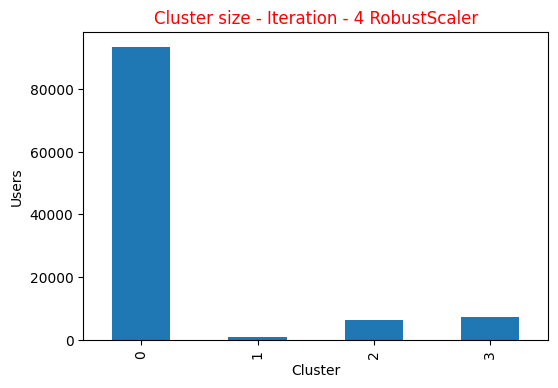

In [0]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4)) 

base_iter['cluster'].value_counts().sort_index().plot(kind= 'bar')
plt.title('Cluster size - Iteration - 4 RobustScaler', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.show()

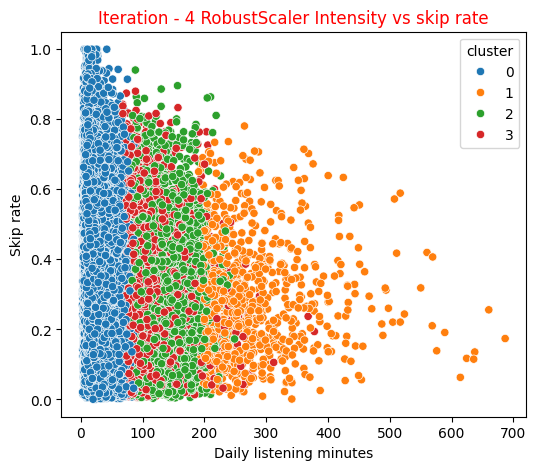

In [0]:
# scatter plot (No PCA)

# intensity vs skip
import seaborn as sns

plt.figure(figsize= (6,5))
sns.scatterplot(
    data = base_iter,
    x = 'daily_listening_minutes',
    y = 'skip_rate',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 4 RobustScaler Intensity vs skip rate', color = 'red')
plt.xlabel('Daily listening minutes')
plt.ylabel('Skip rate')
plt.show()

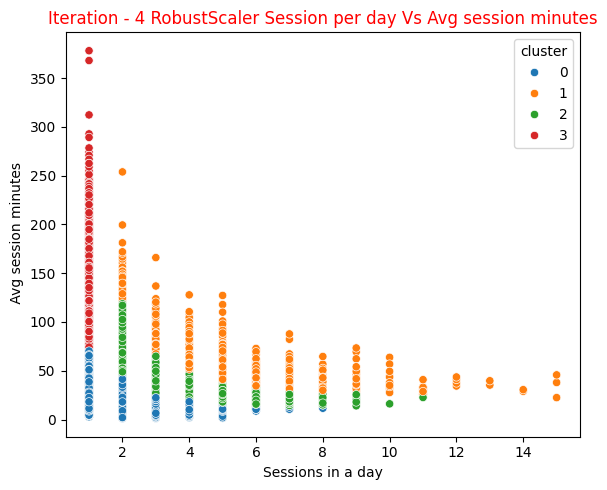

In [0]:
# frequency vs Session depth

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter,
    x = 'sessions_per_day',
    y= 'avg_session_minutes',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 4 RobustScaler Session per day Vs Avg session minutes', color = 'red')
plt.xlabel('Sessions in a day')
plt.ylabel(' Avg session minutes')
plt.tight_layout()
plt.show()

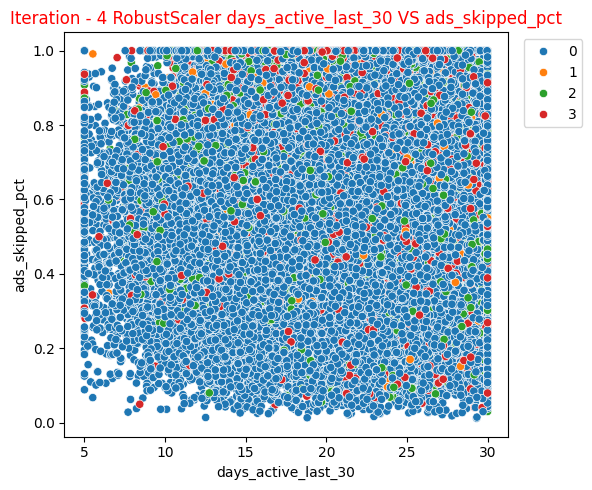

In [0]:
# consistance vs Ad friction

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter,
    x = 'days_active_last_30',
    y= 'ads_skipped_pct',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 4 RobustScaler days_active_last_30 VS ads_skipped_pct', color = 'red')
plt.legend(bbox_to_anchor = (1.02, 1))
plt.tight_layout()
plt.show()

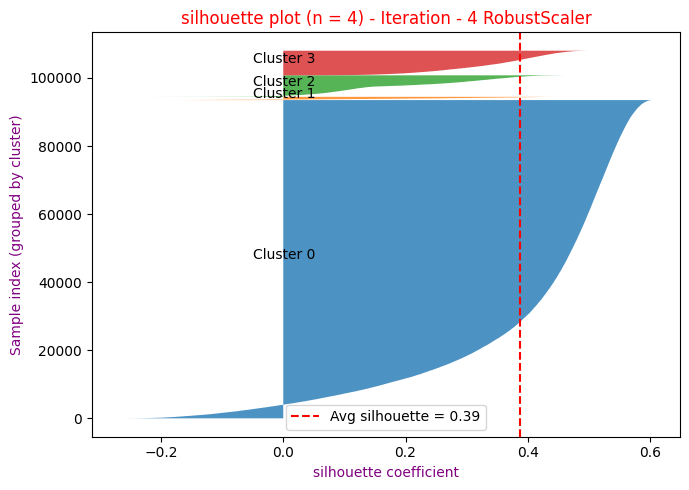

In [0]:
# silhouette Plot

sil_values = silhouette_samples(X1, labels)
sil_avg = silhouette_score(X1, labels)
plt.figure(figsize= (7,5))

y_lower = 0

vals0 = sil_values[labels == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values[labels==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05, y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values[labels== 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values[labels== 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg:.2f}"
)

plt.title('silhouette plot (n = 4) - Iteration - 4 RobustScaler', color = 'red')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.tight_layout()
plt.show()